## Drones Montréal

#### I. Initialisation

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools
from networkx.algorithms.matching import max_weight_matching
import random
import pickle

In [2]:
#Animation

import time
from IPython.display import clear_output

#### II. Graph

In [5]:
filename = "../database/maps/plateau_mont_royal.gpickle"

with open(filename, 'rb') as f:
    G = pickle.load(f).to_undirected()

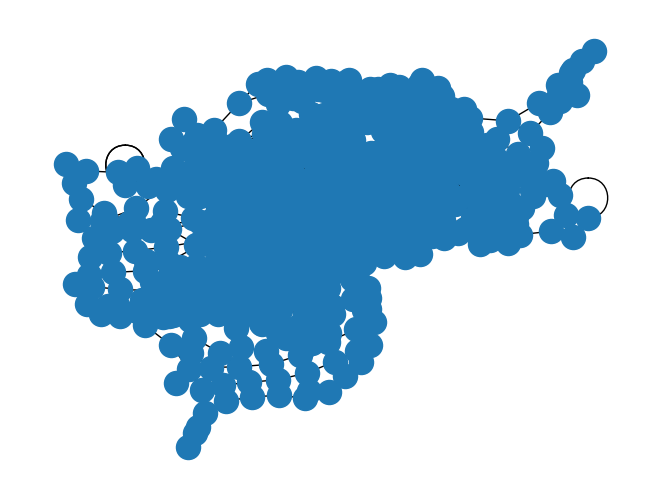

In [6]:
nx.draw(G)

In [7]:
G_bis = nx.MultiGraph(G)

for u, v in G.edges():
    for key in G_bis[u][v]:
        G_bis[u][v][key]['snow'] = random.randint(0,1)

# Trouver les sommets de degre impair
odd_nodes = [v for v, d in G_bis.degree() if d % 2 == 1]

# Generer tous les appariements possibles (pairs sans repetition)
pairs = list(itertools.combinations(odd_nodes, 2))

# Calculer la distance la plus courte entre chaque paire
pair_weights = {}
for u, v in pairs:
    length = nx.dijkstra_path_length(G_bis, u, v, weight='length')
    pair_weights[(u, v)] = length

# Trouver les chemins de distance minimale pour chaque paire de nœuds
neg_weights = {pair: -w for pair, w in pair_weights.items()}
matching_graph = nx.Graph([(u, v, {'weight': neg_weights[(u, v)]}) for (u, v) in neg_weights])
matching = max_weight_matching(matching_graph, maxcardinality=True)

# Ajouter les aretes necessaires (dans un MultiGraph)
G_aug = nx.MultiGraph(G)  # copie avec aretes multiples autorisees
for u, v in matching:
    path = nx.dijkstra_path(G, u, v, weight='length')
    path_edges = list(zip(path[:-1], path[1:]))
    for edge in path_edges:
        weight = G_bis[edge[0]][edge[1]][0]['length']
        G_aug.add_edge(edge[0], edge[1], weight=weight)


# Maintenant que tous les sommets ont un degre pair, on peut trouver un circuit eulerien
print("Ce graphe est eulerien :", nx.is_eulerian(G_aug))
circuit = list(nx.eulerian_circuit(G_aug))

Ce graphe est eulerien : True


In [8]:
def snow_roads(G_aug, G_bis):
    circuit = list(nx.eulerian_circuit(G_aug))
    edges = []
    for i, (u, v) in enumerate(circuit):
        for key in G_bis[u][v]:
            if G_bis[u][v][key]['snow']:
                edges.append((u, v, key))

    return edges

snow_edges = snow_roads(G_aug, G_bis)
#print(snow_edges)


In [9]:
# Position geographique reelle
pos = {node: (data['x'], data['y']) for node, data in G_aug.nodes(data=True)}

circuit = list(nx.eulerian_circuit(G_aug))

edges_drawn = []

for i, edge in enumerate(circuit):
    edges_drawn.append(edge)

    clear_output(wait=True)
    plt.figure(figsize=(12, 12))

    options = {"edgecolors": "tab:gray", "node_size": 1, "alpha": 0.8}
    nx.draw_networkx_nodes(G_aug, pos, node_color="tab:blue", **options)

    nx.draw_networkx_edges(G_aug, pos, width=0.5, alpha=0.2, edge_color="gray")

    nx.draw_networkx_edges(
        G_aug,
        pos,
        edgelist=snow_edges,
        width=1,
        alpha=0.5,
        edge_color="tab:blue",
    )
    
    nx.draw_networkx_edges(
        G_aug,
        pos,
        edgelist=edges_drawn,
        width=2,
        alpha=0.9,
        edge_color="tab:red",
    )

    plt.title(f"Étape {i+1} / {len(circuit)}", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

KeyboardInterrupt: 

### III. Comparaison

In [7]:
def sum_dist(G):
    s = 0
    for u, v in G.edges():
        for key in G[u][v]:
            s += G[u][v][key]['length']
    return s

sum_dist(G)

131258.32003074573

In [21]:
def sum_dist_circuit(G_bis, circuit):
    s = 0
    for i, (u, v) in enumerate(circuit):
        for key in G_bis[u][v]:
            if G_bis[u][v][key]['length']:
                s += G_bis[u][v][key]['length']
    km = s/1000
    cout = km/100
    print("Distance du circuit = " + str(round(km, 2)) + " km.")
    print("Cout du circuit = " + str(round(cout, 2)) + " €.")
    return s

sum_dist_circuit(G_bis, circuit)

Distance du circuit = 147.94 km.
Cout du circuit = 1.48 €.


147936.3409693473

#### Exporter

In [27]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import networkx as nx

pos = {node: (data['x'], data['y']) for node, data in G_aug.nodes(data=True)}

circuit = path_charue
fig, ax = plt.subplots(figsize=(12, 12))
step = 4 
frames = list(range(0, len(circuit), step))
frames.append(len(circuit) - 1)

def update(i):
    ax.clear()
    ax.set_title(f"Étape {i+1} / {len(circuit)}", fontsize=16)
    ax.axis("off")

    edges_drawn = circuit[:i]

    # Dessin des nœuds
    nx.draw_networkx_nodes(G_aug, pos, node_color="tab:blue", node_size=1, alpha=0.8, ax=ax)

    # Arêtes de fond
    nx.draw_networkx_edges(G_aug, pos, width=0.5, alpha=0.2, edge_color="gray", ax=ax)

    # Arêtes enneigee en bleu
    nx.draw_networkx_edges(
        G_aug,
        pos,
        edgelist=snow_edges,
        width=1,
        alpha=0.5,
        edge_color="tab:blue",
    )
    
    # Arêtes rouges du circuit parcouru
    nx.draw_networkx_edges(
        G_aug,
        pos,
        edgelist=edges_drawn,
        width=2,
        alpha=0.9,
        edge_color="tab:red",
        ax=ax,
    )

ani = animation.FuncAnimation(fig, update, frames=frames, interval=40)
ani.save("deneigeuse_plateau_mr_light.mp4", writer='ffmpeg', fps=25)

plt.close()
